In [5]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from collections import Counter
from wordcloud import WordCloud
from scipy.sparse import vstack

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve, KFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import SelectKBest, chi2

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPool1D, Dense, Dropout, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

sns.set(style="whitegrid")
%matplotlib inline

## Dataset Exploration

In [7]:
train_data = pd.read_csv('/kaggle/input/jigsaw-toxic-comment-classification-challenge/train.csv.zip')
test_data = pd.read_csv('/kaggle/input/jigsaw-toxic-comment-classification-challenge/test.csv.zip')

print(train_data.shape)
display(train_data.head())
print(list(train_data.columns))

label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

(159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


## Label Frequencies

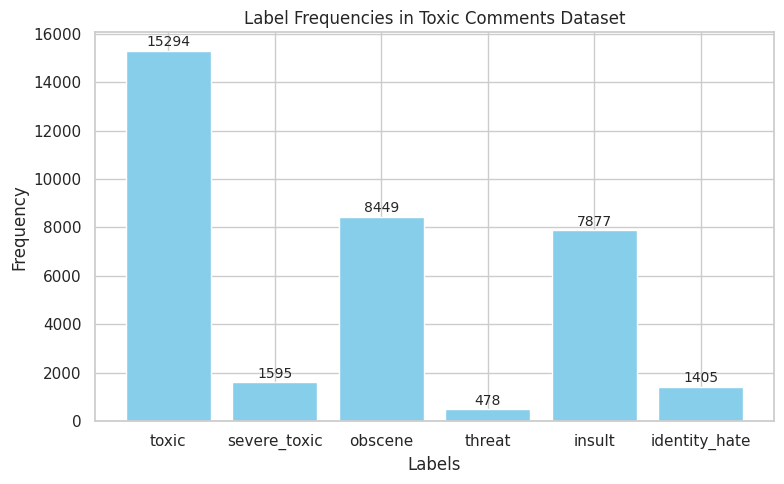

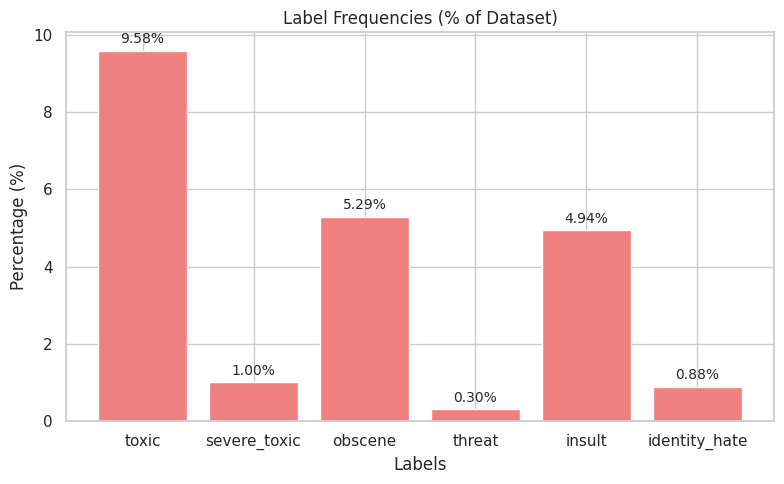

In [8]:
label_frequencies = train_data[label_cols].sum()

plt.figure(figsize=(8,5))
plt.bar(label_frequencies.index, label_frequencies.values, color='skyblue')
for idx, value in enumerate(label_frequencies.values):
    plt.text(idx, value + 200, str(value), ha='center', fontsize=10)
plt.xlabel('Labels')
plt.ylabel('Frequency')
plt.title('Label Frequencies in Toxic Comments Dataset')
plt.tight_layout()
plt.show()

total = len(train_data)
label_percent = (label_frequencies / total) * 100

plt.figure(figsize=(8,5))
plt.bar(label_percent.index, label_percent.values, color='lightcoral')
for idx, value in enumerate(label_percent.values):
    plt.text(idx, value + 0.2, f"{value:.2f}%", ha='center', fontsize=10)
plt.xlabel('Labels')
plt.ylabel('Percentage (%)')
plt.title('Label Frequencies (% of Dataset)')
plt.tight_layout()
plt.show()

## Text Length Analysis

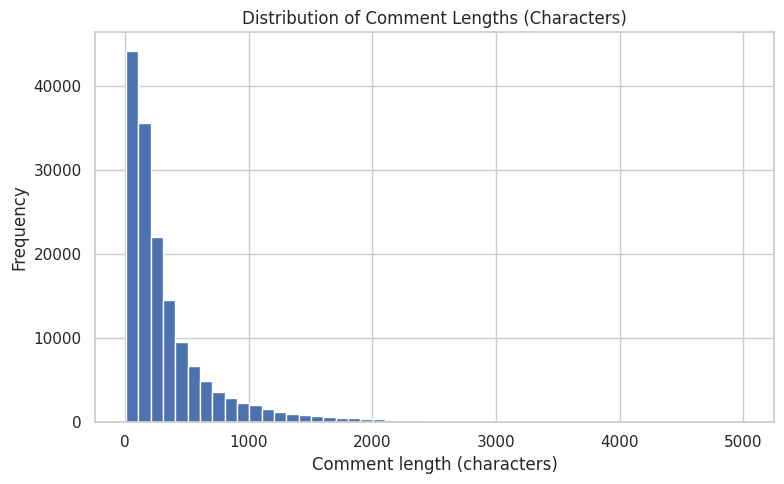

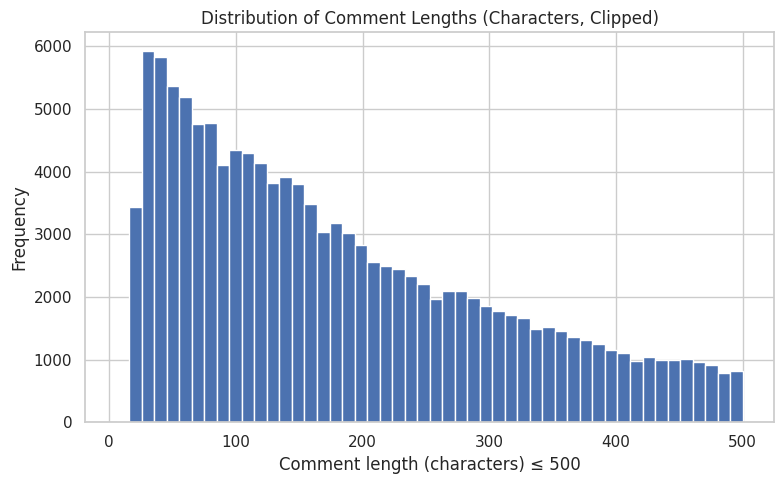

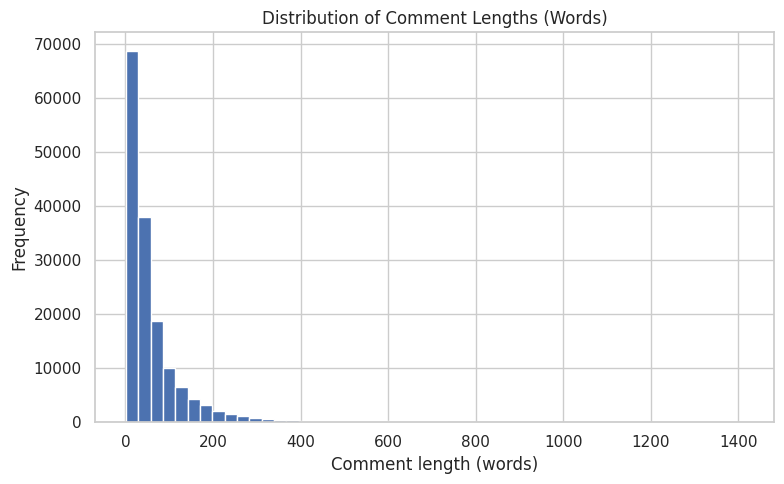

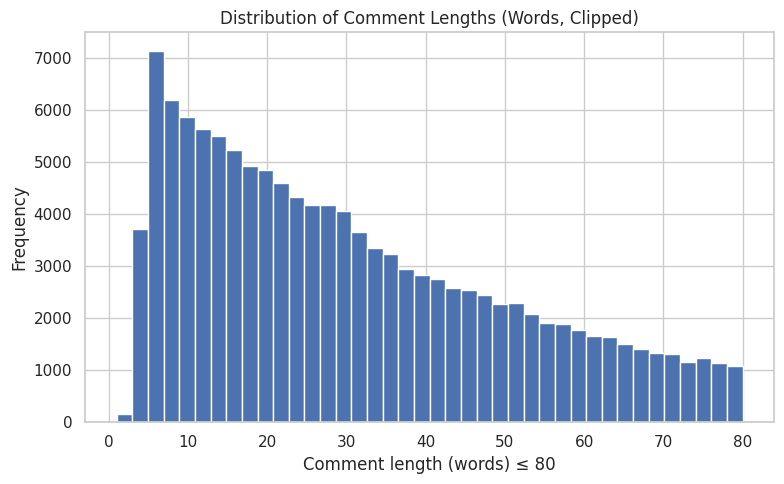

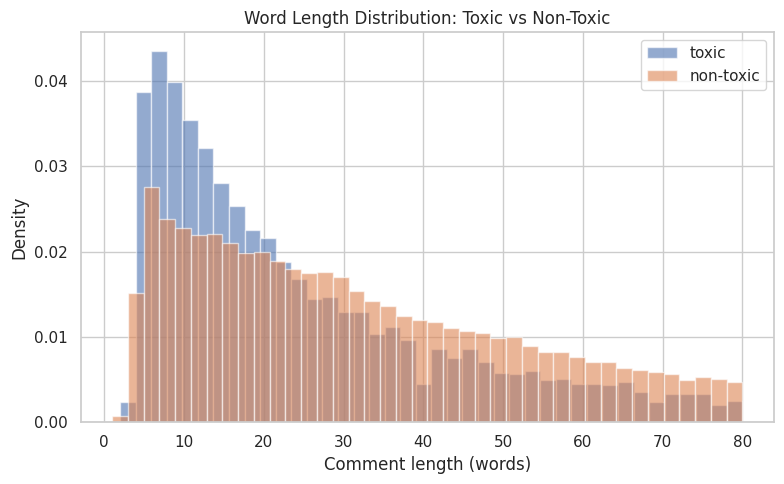

[{'group': 'toxic',
  'mean': 24.364179782082324,
  'median': 18.0,
  'p90': 53.0,
  'p95': 64.0,
  'max': 80},
 {'group': 'non-toxic',
  'mean': 31.086923175252462,
  'median': 27.0,
  'p90': 63.0,
  'p95': 71.0,
  'max': 80}]

In [9]:
text_col = "comment_text"
train_data["char_len"] = train_data[text_col].astype(str).str.len()
train_data["word_len"] = train_data[text_col].astype(str).str.split().str.len()

plt.figure(figsize=(8, 5))
plt.hist(train_data["char_len"], bins=50)
plt.xlabel("Comment length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Comment Lengths (Characters)")
plt.tight_layout()
plt.show()

max_chars = 500
subset = train_data[train_data["char_len"] <= max_chars]

plt.figure(figsize=(8, 5))
plt.hist(subset["char_len"], bins=50)
plt.xlabel(f"Comment length (characters) ≤ {max_chars}")
plt.ylabel("Frequency")
plt.title("Distribution of Comment Lengths (Characters, Clipped)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(train_data["word_len"], bins=50)
plt.xlabel("Comment length (words)")
plt.ylabel("Frequency")
plt.title("Distribution of Comment Lengths (Words)")
plt.tight_layout()
plt.show()

max_words = 80
subset_words = train_data[train_data["word_len"] <= max_words]

plt.figure(figsize=(8, 5))
plt.hist(subset_words["word_len"], bins=40)
plt.xlabel(f"Comment length (words) ≤ {max_words}")
plt.ylabel("Frequency")
plt.title("Distribution of Comment Lengths (Words, Clipped)")
plt.tight_layout()
plt.show()

label = "toxic"
max_words = 80
subset_words = train_data[train_data["word_len"] <= max_words]
toxic_comments = subset_words[subset_words[label] == 1]
nontoxic_comments = subset_words[subset_words[label] == 0]

plt.figure(figsize=(8, 5))
plt.hist(toxic_comments["word_len"], bins=40, alpha=0.6, label="toxic", density=True)
plt.hist(nontoxic_comments["word_len"], bins=40, alpha=0.6, label="non-toxic", density=True)
plt.xlabel("Comment length (words)")
plt.ylabel("Density")
plt.title("Word Length Distribution: Toxic vs Non-Toxic")
plt.legend()
plt.tight_layout()
plt.show()

def length_summary(df, col, name):
    return {
        "group": name,
        "mean": df[col].mean(),
        "median": df[col].median(),
        "p90": np.percentile(df[col], 90),
        "p95": np.percentile(df[col], 95),
        "max": df[col].max()
    }

summary_stats = [
    length_summary(toxic_comments, "word_len", "toxic"),
    length_summary(nontoxic_comments, "word_len", "non-toxic"),
]
display(summary_stats)

## Length Boxplots

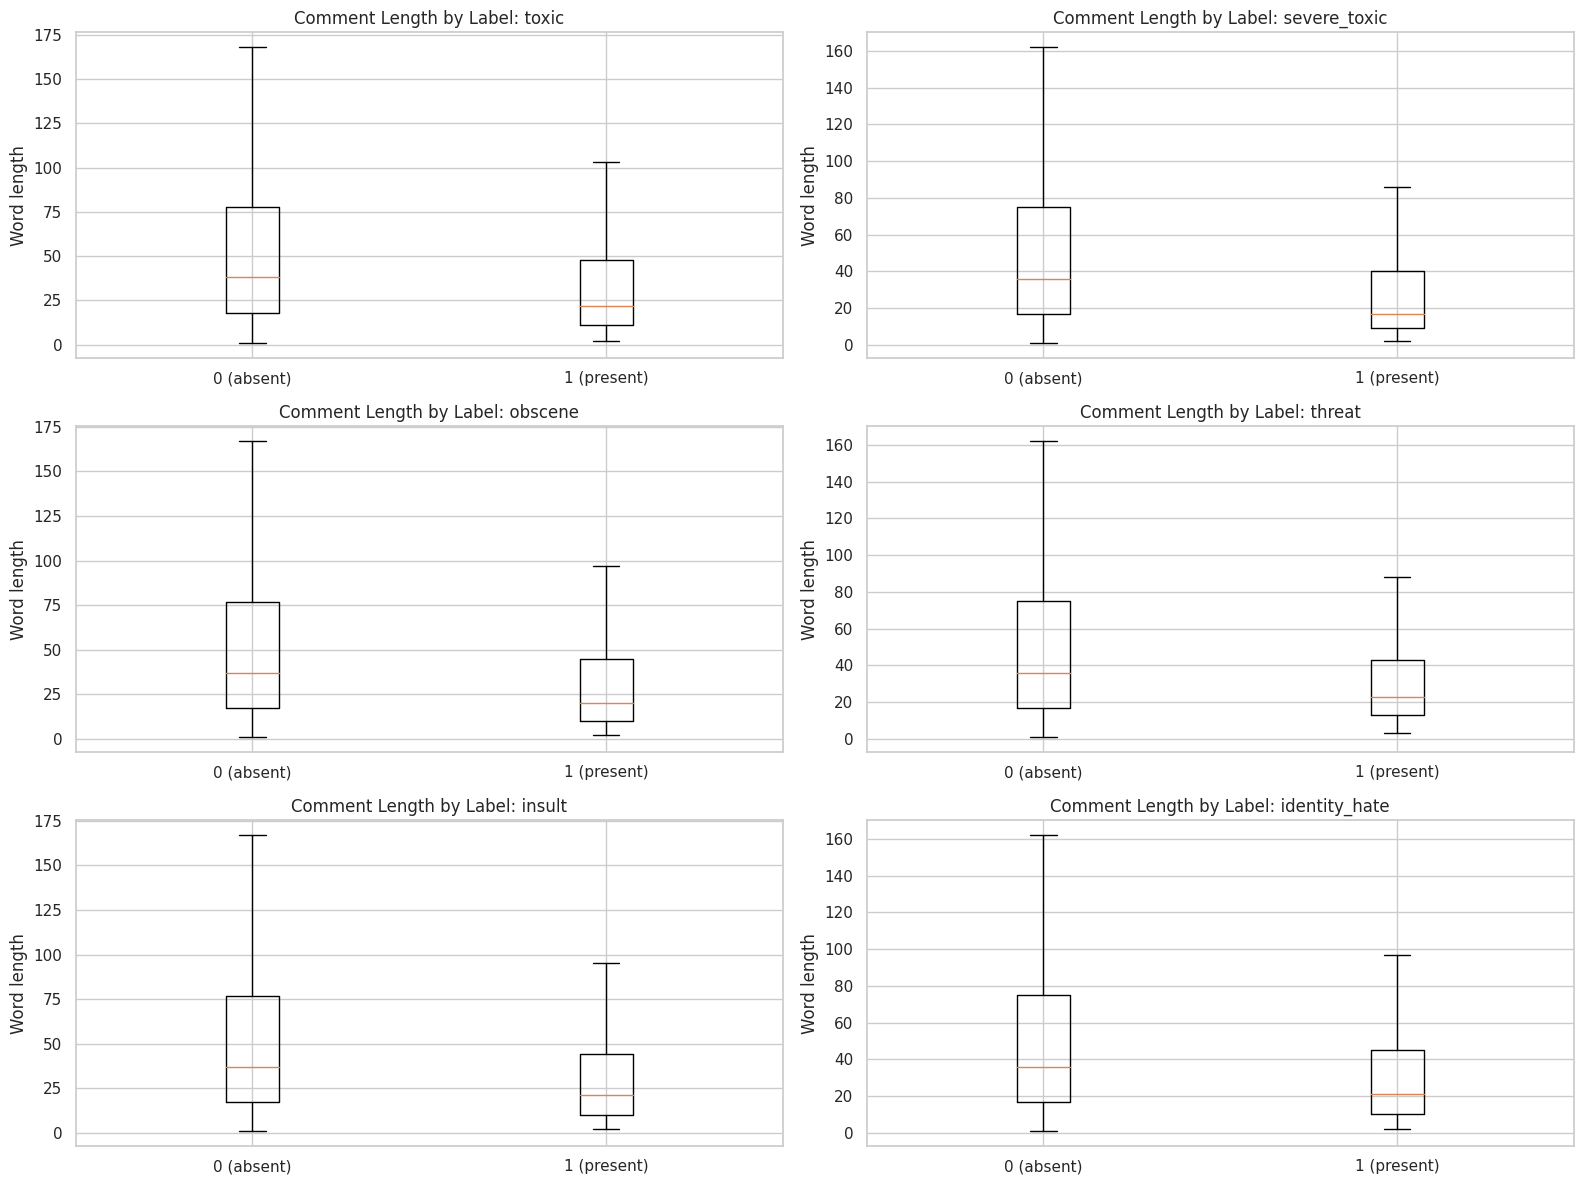

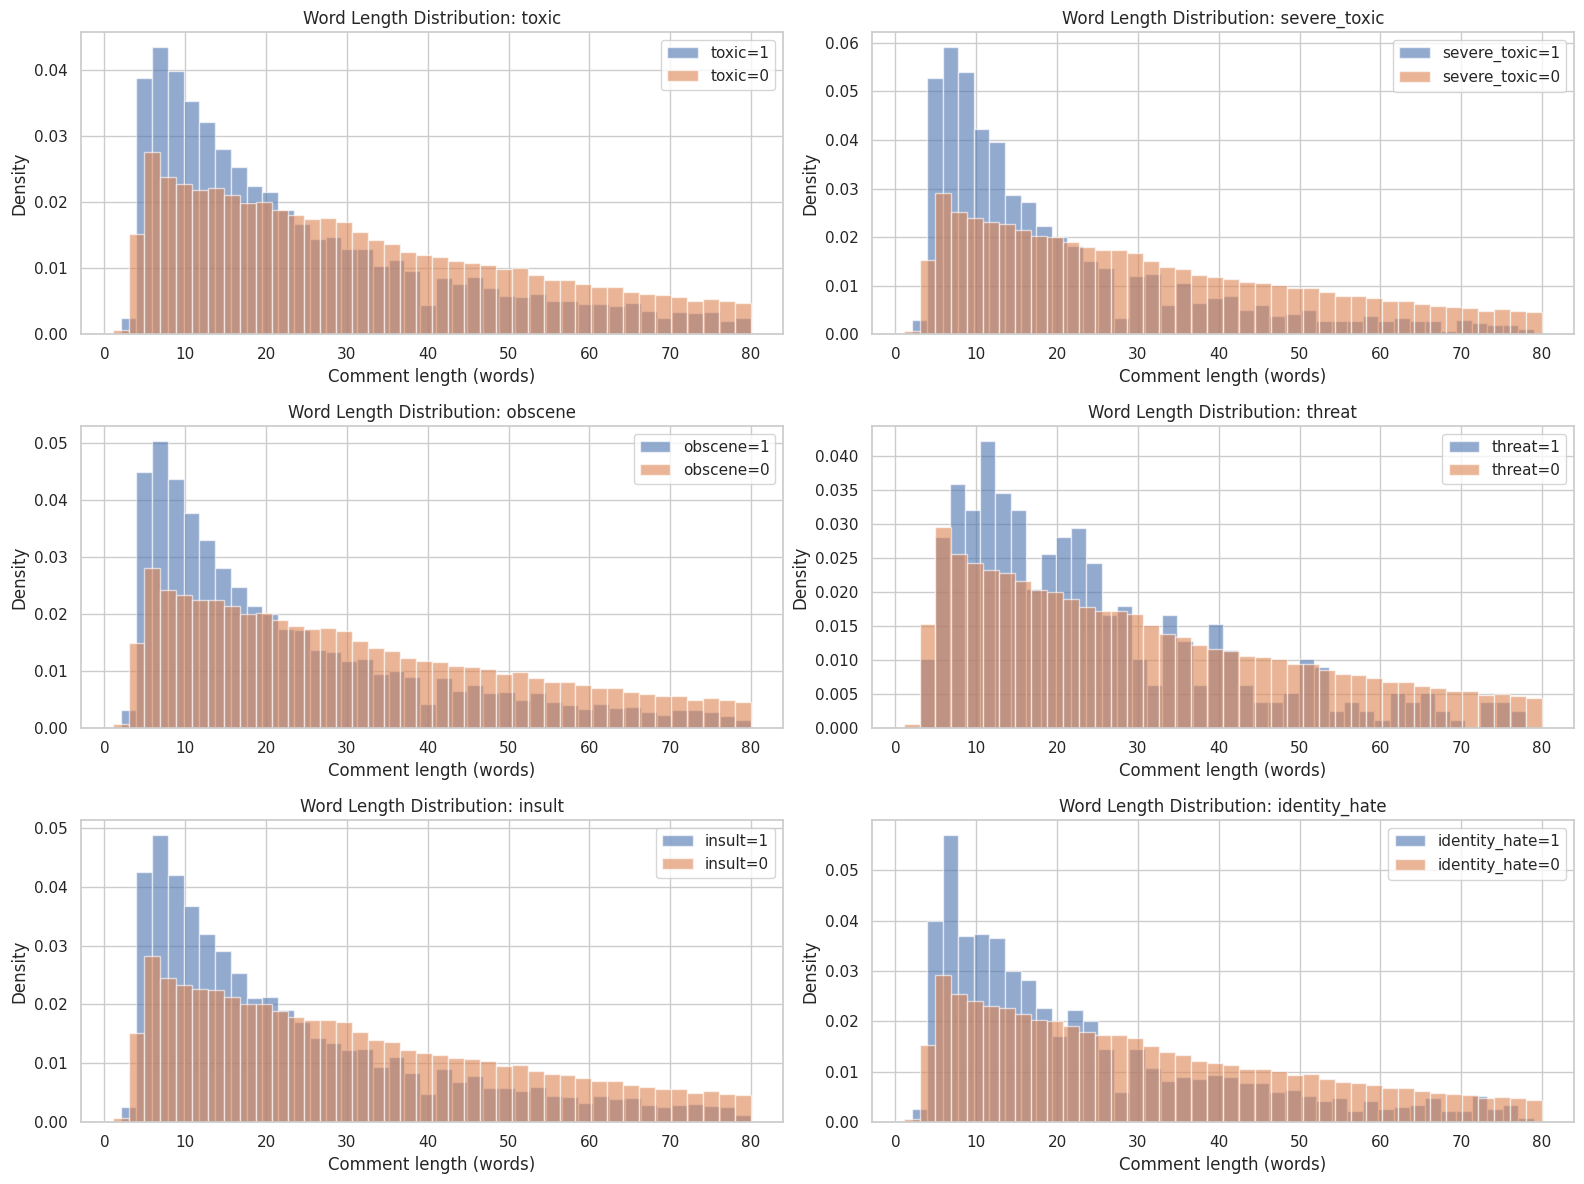

In [10]:
plt.figure(figsize=(16, 12))
for idx, label in enumerate(label_cols, 1):
    plt.subplot(3, 2, idx)
    data_to_plot = [
        train_data.loc[train_data[label] == 0, "word_len"],
        train_data.loc[train_data[label] == 1, "word_len"]
    ]
    plt.boxplot(data_to_plot, labels=["0 (absent)", "1 (present)"], showfliers=False)
    plt.ylabel("Word length")
    plt.title(f"Comment Length by Label: {label}")
plt.tight_layout()
plt.show()

max_words = 80
subset = train_data[train_data["word_len"] <= max_words]
plt.figure(figsize=(16, 12))
for idx, label in enumerate(label_cols, 1):
    toxic_c = subset[subset[label] == 1]
    nontoxic_c = subset[subset[label] == 0]
    plt.subplot(3, 2, idx)
    plt.hist(toxic_c["word_len"], bins=40, alpha=0.6, density=True, label=f"{label}=1")
    plt.hist(nontoxic_c["word_len"], bins=40, alpha=0.6, density=True, label=f"{label}=0")
    plt.title(f"Word Length Distribution: {label}")
    plt.xlabel("Comment length (words)")
    plt.ylabel("Density")
    plt.legend()
plt.tight_layout()
plt.show()

## Co-Occurrence


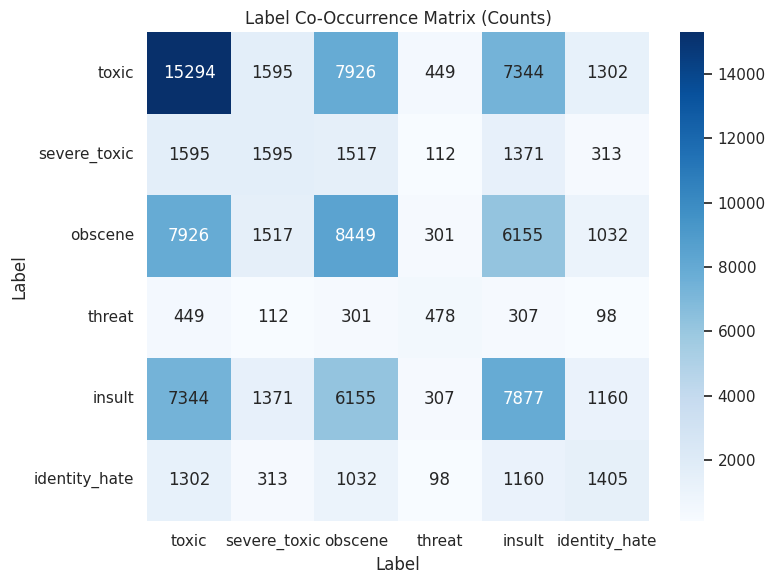

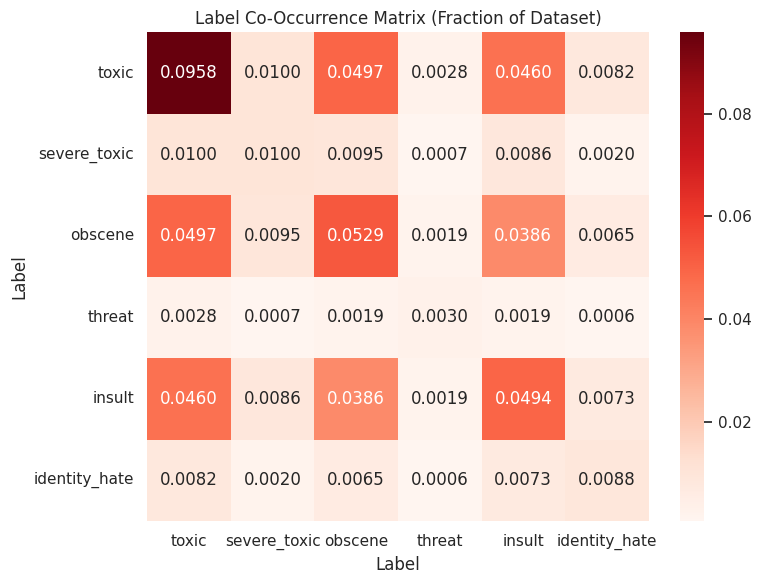

In [11]:
co_occurrence = pd.DataFrame(0, index=label_cols, columns=label_cols)
for label1 in label_cols:
    for label2 in label_cols:
        co_occurrence.loc[label1, label2] = ((train_data[label1] == 1) & (train_data[label2] == 1)).sum()

co_occurrence_norm = co_occurrence / len(train_data)

plt.figure(figsize=(8, 6))
sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="Blues")
plt.title("Label Co-Occurrence Matrix (Counts)")
plt.ylabel("Label")
plt.xlabel("Label")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(co_occurrence_norm, annot=True, fmt=".4f", cmap="Reds")
plt.title("Label Co-Occurrence Matrix (Fraction of Dataset)")
plt.ylabel("Label")
plt.xlabel("Label")
plt.tight_layout()
plt.show()

## Data Quality Checks

In [12]:
train_data["comment_text"] = train_data["comment_text"].astype(str)
empty_mask = train_data["comment_text"].str.strip() == ""
empty_comments = train_data[empty_mask]
print("Empty or whitespace-only comments:", len(empty_comments))

very_short = train_data[train_data["word_len"] <= 2]
print("Comments with 1–2 words:", len(very_short))

def only_punctuation(text):
    return re.fullmatch(r"[^\w\s]+", text.strip()) is not None

punct_mask = train_data["comment_text"].apply(only_punctuation)
only_punctuation_comments = train_data[punct_mask]
print("Comments with only punctuation:", len(only_punctuation_comments))

emoji_pattern = re.compile(
    "[" 
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    "]+", flags=re.UNICODE)

def only_emojis(text):
    text = text.strip()
    return emoji_pattern.fullmatch(text) is not None

emoji_mask = train_data["comment_text"].apply(only_emojis)
emoji_only_comments = train_data[emoji_mask]
print("Comments with only emojis:", len(emoji_only_comments))

duplicate_mask = train_data["comment_text"].duplicated(keep=False)
duplicates = train_data[duplicate_mask]
print("Number of duplicated comments:", duplicates["comment_text"].nunique())

summary_checks = {
    "empty_or_whitespace": len(empty_comments),
    "one_or_two_words": len(very_short),
    "only_punctuation": len(only_punctuation_comments),
    "only_emojis": len(emoji_only_comments),
    "duplicated_comments": duplicates["comment_text"].nunique(),
}
display(summary_checks)

Empty or whitespace-only comments: 0
Comments with 1–2 words: 165
Comments with only punctuation: 0
Comments with only emojis: 0
Number of duplicated comments: 0


{'empty_or_whitespace': 0,
 'one_or_two_words': 165,
 'only_punctuation': 0,
 'only_emojis': 0,
 'duplicated_comments': 0}

## Profanity Analysis

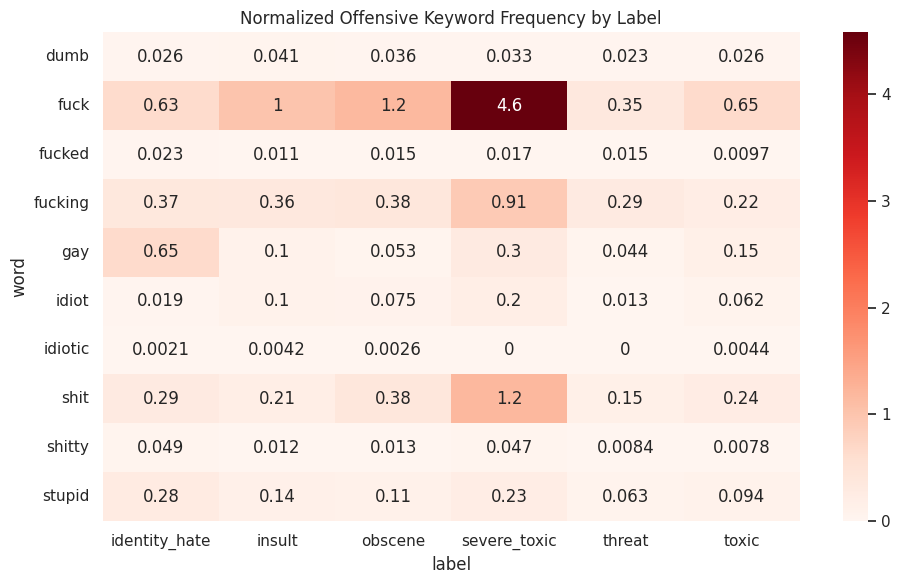

In [13]:
profanity_words = [
    "fuck", "fucking", "fucked",
    "shit", "shitty",
    "idiot", "idiotic",
    "stupid", "dumb",
    "gay"
]

train_data["text_lower"] = train_data["comment_text"].str.lower()

def count_word(df, word):
    return df["text_lower"].str.count(rf"\b{re.escape(word)}\b").sum()

rows = []
for word in profanity_words:
    for label in label_cols:
        subset = train_data[train_data[label] == 1]
        count = subset["text_lower"].str.count(rf"\b{re.escape(word)}\b").sum()
        rows.append([word, label, count])

profanity_by_label = pd.DataFrame(rows, columns=["word", "label", "count"])
label_sizes = train_data[label_cols].sum()

profanity_by_label["normalized"] = profanity_by_label.apply(
    lambda row: row["count"] / label_sizes[row["label"]] if label_sizes[row["label"]] > 0 else 0,
    axis=1
)

heatmap_data = profanity_by_label.pivot(index="word", columns="label", values="normalized")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap="Reds")
plt.title("Normalized Offensive Keyword Frequency by Label")
plt.tight_layout()
plt.show()

## Character Level Patterns

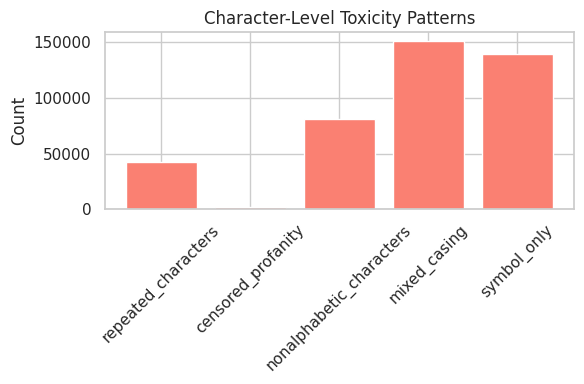

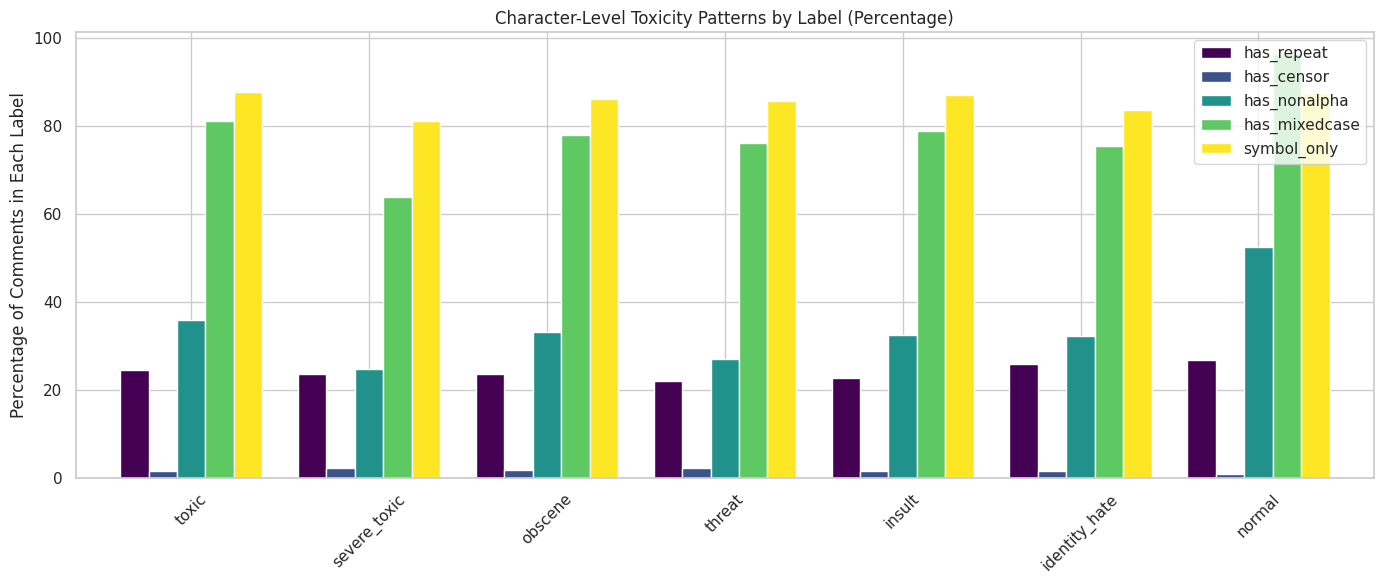

In [14]:
def has_repeated_chars(text):
    return re.search(r"(.)\1{2,}", text) is not None

train_data["has_repeat"] = train_data["comment_text"].apply(has_repeated_chars)
repeat_count = train_data["has_repeat"].sum()

censored_pattern = re.compile(r"f[\W_]*c?k", re.IGNORECASE)
def has_censored_profanity(text):
    return bool(censored_pattern.search(text))

train_data["has_censor"] = train_data["comment_text"].apply(has_censored_profanity)
censor_count = train_data["has_censor"].sum()

def has_non_alpha(text):
    return bool(re.search(r"[0-9@#\$%\^&\*\-_/\\]", text))

train_data["has_nonalpha"] = train_data["comment_text"].apply(has_non_alpha)
nonalpha_count = train_data["has_nonalpha"].sum()

def mixed_case(text):
    return bool(re.search(r"[A-Z].*[a-z]|[a-z].*[A-Z]", text))

train_data["has_mixedcase"] = train_data["comment_text"].apply(mixed_case)
mixedcase_count = train_data["has_mixedcase"].sum()

def is_symbol_only(text):
    stripped = re.sub(r"\s+", "", text)
    return stripped != "" and stripped.isascii() and stripped.isprintable() and stripped.isalpha() == False and stripped.isdigit() == False

train_data["symbol_only"] = train_data["comment_text"].apply(is_symbol_only)
symbol_only_count = train_data["symbol_only"].sum()

char_summary = {
    "repeated_characters": repeat_count,
    "censored_profanity": censor_count,
    "nonalphabetic_characters": nonalpha_count,
    "mixed_casing": mixedcase_count,
    "symbol_only": symbol_only_count
}

plt.figure(figsize=(6,4))
plt.bar(char_summary.keys(), char_summary.values(), color="salmon")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.title("Character-Level Toxicity Patterns")
plt.tight_layout()
plt.show()

train_data["normal"] = (train_data[label_cols].sum(axis=1) == 0).astype(int)
extended_labels = label_cols + ["normal"]
char_features = ["has_repeat", "has_censor", "has_nonalpha", "has_mixedcase", "symbol_only"]

results = {}
for label in extended_labels:
    subset = train_data[train_data[label] == 1]
    results[label] = {feat: subset[feat].sum() for feat in char_features}

char_by_label = pd.DataFrame(results).T
label_sizes_ext = train_data[extended_labels].sum()
percent_df = char_by_label.div(label_sizes_ext, axis=0) * 100

percent_df.plot(kind="bar", figsize=(14, 6), colormap="viridis", width=0.8)
plt.title("Character-Level Toxicity Patterns by Label (Percentage)")
plt.ylabel("Percentage of Comments in Each Label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Top Words Analysis

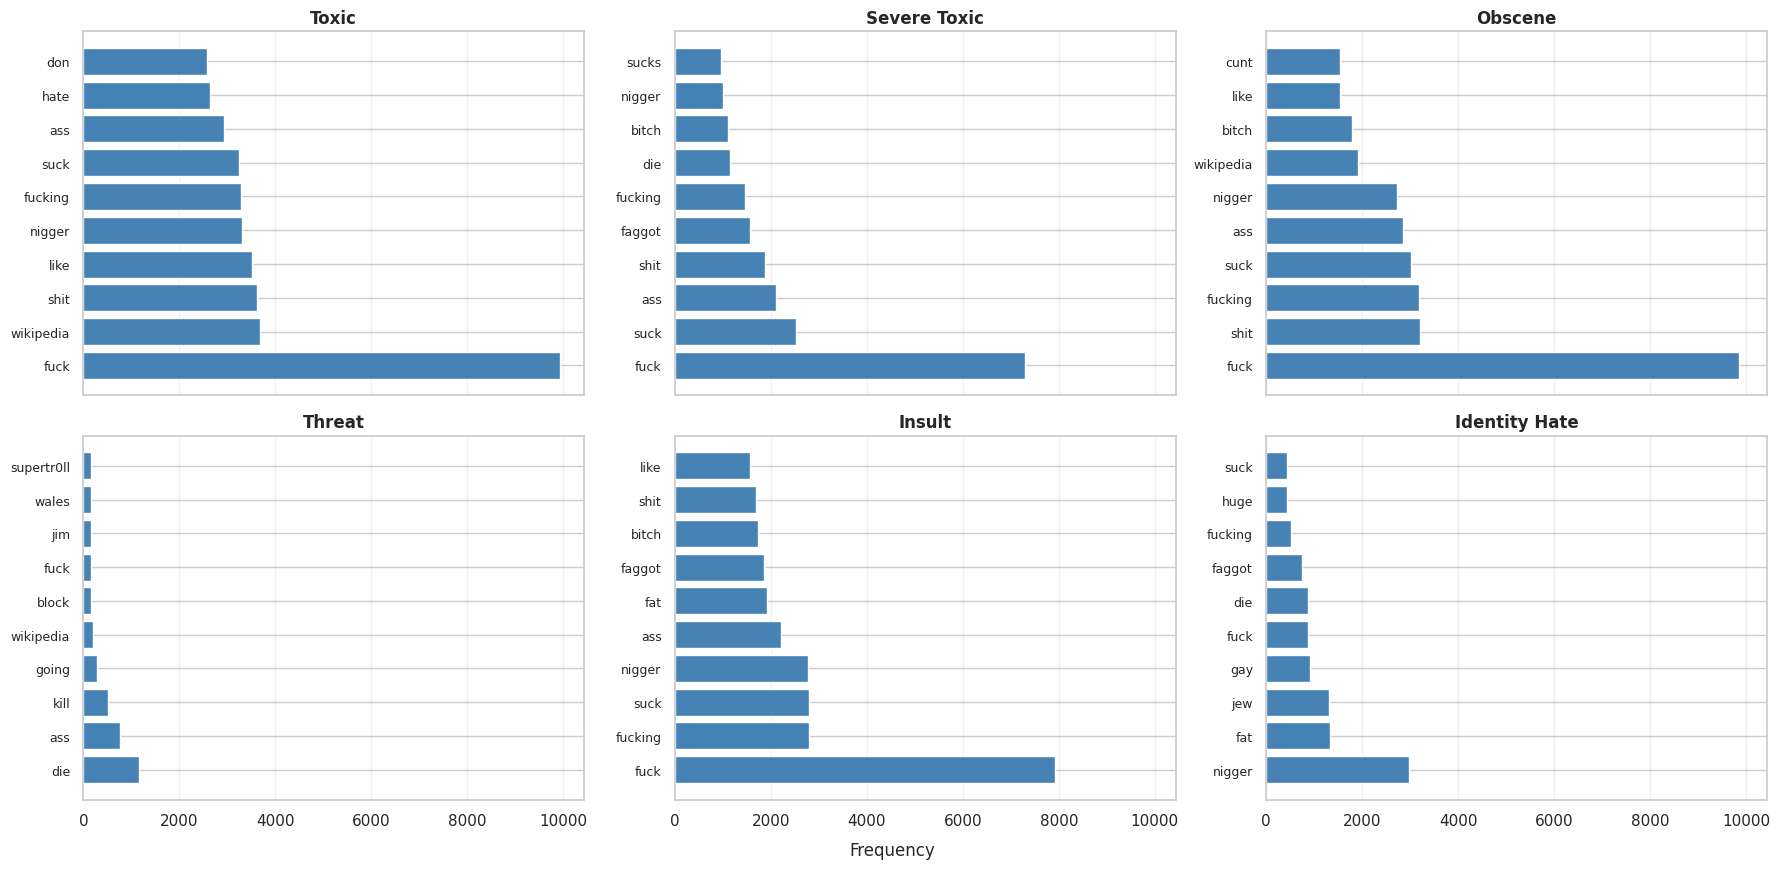

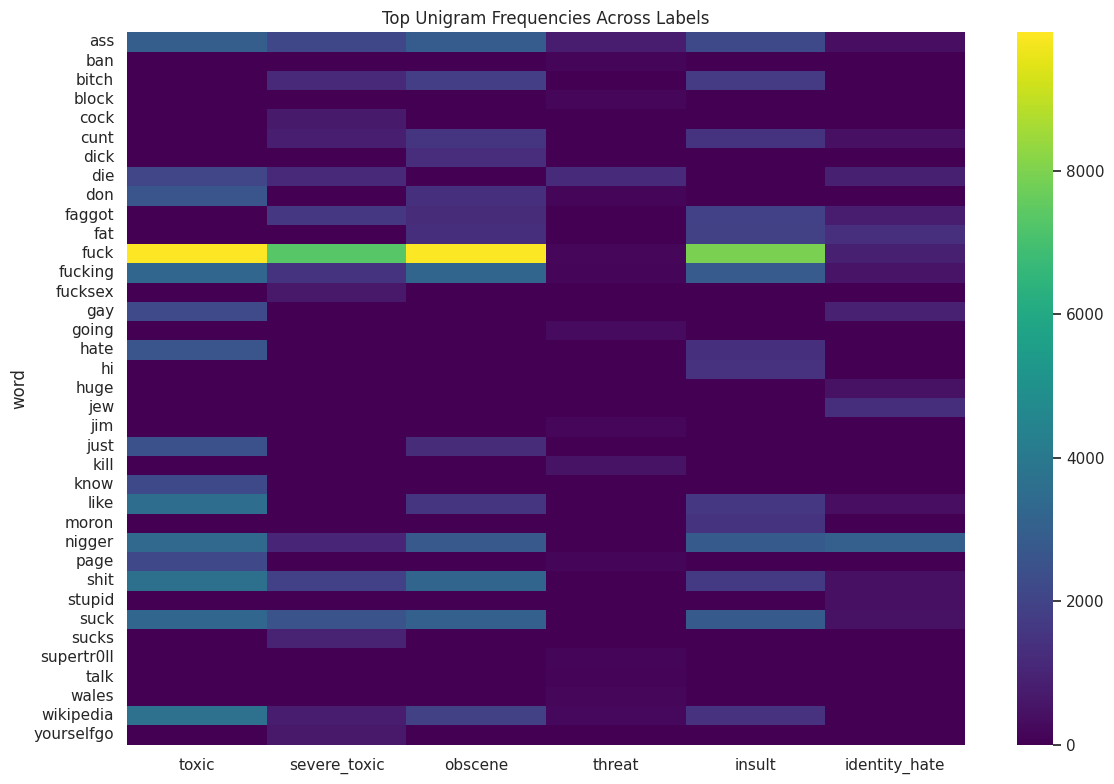

In [15]:
def top_words_for_label(df, label, n=20):
    subset = df[df[label] == 1]["text_lower"]
    vec = CountVectorizer(stop_words="english")
    X = vec.fit_transform(subset)
    freqs = np.array(X.sum(axis=0)).flatten()
    vocab = np.array(vec.get_feature_names_out())
    top_idx = freqs.argsort()[::-1][:n]
    return pd.DataFrame({"word": vocab[top_idx], "count": freqs[top_idx]})

top_unigrams = {label: top_words_for_label(train_data, label) for label in label_cols}

def top_bigrams_for_label(df, label, n=20):
    subset = df[df[label] == 1]["text_lower"]
    vec = CountVectorizer(ngram_range=(2,2), stop_words="english")
    X = vec.fit_transform(subset)
    freqs = np.array(X.sum(axis=0)).flatten()
    vocab = np.array(vec.get_feature_names_out())
    top_idx = freqs.argsort()[::-1][:n]
    return pd.DataFrame({"bigram": vocab[top_idx], "count": freqs[top_idx]})

top_bigrams = {label: top_bigrams_for_label(train_data, label) for label in label_cols}

def label_top_words(df, label, n=15):
    uni = top_words_for_label(df, label, n)
    bi = top_bigrams_for_label(df, label, n)
    return uni, bi

label_summary = {label: label_top_words(train_data, label) for label in label_cols}

max_count = 0
for label in label_cols:
    uni = label_summary[label][0].head(10)
    max_count = max(max_count, uni["count"].max())

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
axes = axes.flatten()

for ax, label in zip(axes, label_cols):
    uni = label_summary[label][0].head(10)
    words = uni["word"].values[::-1]
    counts = uni["count"].values[::-1]
    y_pos = np.arange(len(words))
    ax.barh(y_pos, counts, color="steelblue")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f"{label.replace('_',' ').title()}", fontsize=12, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

axes[-1].set_xlim(0, max_count * 1.05)
fig.text(0.5, 0.04, "Frequency", ha="center", fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

heatmap_df = pd.DataFrame({
    label: label_summary[label][0].set_index("word")["count"]
    for label in label_summary
}).fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df, cmap="viridis", annot=False)
plt.title("Top Unigram Frequencies Across Labels")
plt.tight_layout()
plt.show()

## TF-IDF Distinguishing Words

In [16]:
vec = TfidfVectorizer(stop_words="english", min_df=5)
X = vec.fit_transform(train_data["text_lower"])
vocab = np.array(vec.get_feature_names_out())

toxic_mask = (train_data["toxic"] == 1).to_numpy()
normal_mask = (train_data["normal"] == 1).to_numpy()

toxic_tfidf = X[toxic_mask].mean(axis=0).A1
normal_tfidf = X[normal_mask].mean(axis=0).A1

diff = toxic_tfidf - normal_tfidf
top_idx = np.argsort(diff)[-25:][::-1]
top_toxic_words = vocab[top_idx]
display(pd.DataFrame({"word": top_toxic_words, "score_diff": diff[top_idx]}))

insult_mask = (train_data["insult"] == 1).to_numpy()
obscene_mask = (train_data["obscene"] == 1).to_numpy()

insult_tfidf = X[insult_mask].mean(axis=0).A1
obscene_tfidf = X[obscene_mask].mean(axis=0).A1

diff2 = insult_tfidf - obscene_tfidf
diff3 = obscene_tfidf - insult_tfidf

top_insult_idx = np.argsort(diff2)[-20:][::-1]
top_insult_words = vocab[top_insult_idx]

top_obscene_idx = np.argsort(diff3)[-20:][::-1]
top_obscene_words = vocab[top_obscene_idx]

display(pd.DataFrame({
    "insult_words": top_insult_words,
    "obscene_words": top_obscene_words
}))

,word,score_diff
0,fuck,0.050625
1,fucking,0.029359
2,shit,0.020892
3,bitch,0.015262
4,ass,0.015216
5,suck,0.015115
6,stupid,0.014889
7,asshole,0.012088
8,idiot,0.011411
9,gay,0.011203


,insult_words,obscene_words
0,idiot,fuck
1,stupid,fucking
2,gay,shit
3,loser,bullshit
4,pathetic,ass
5,retarded,dick
6,moron,suck
7,idiots,penis
8,retard,cock
9,fool,damn


## WordClouds

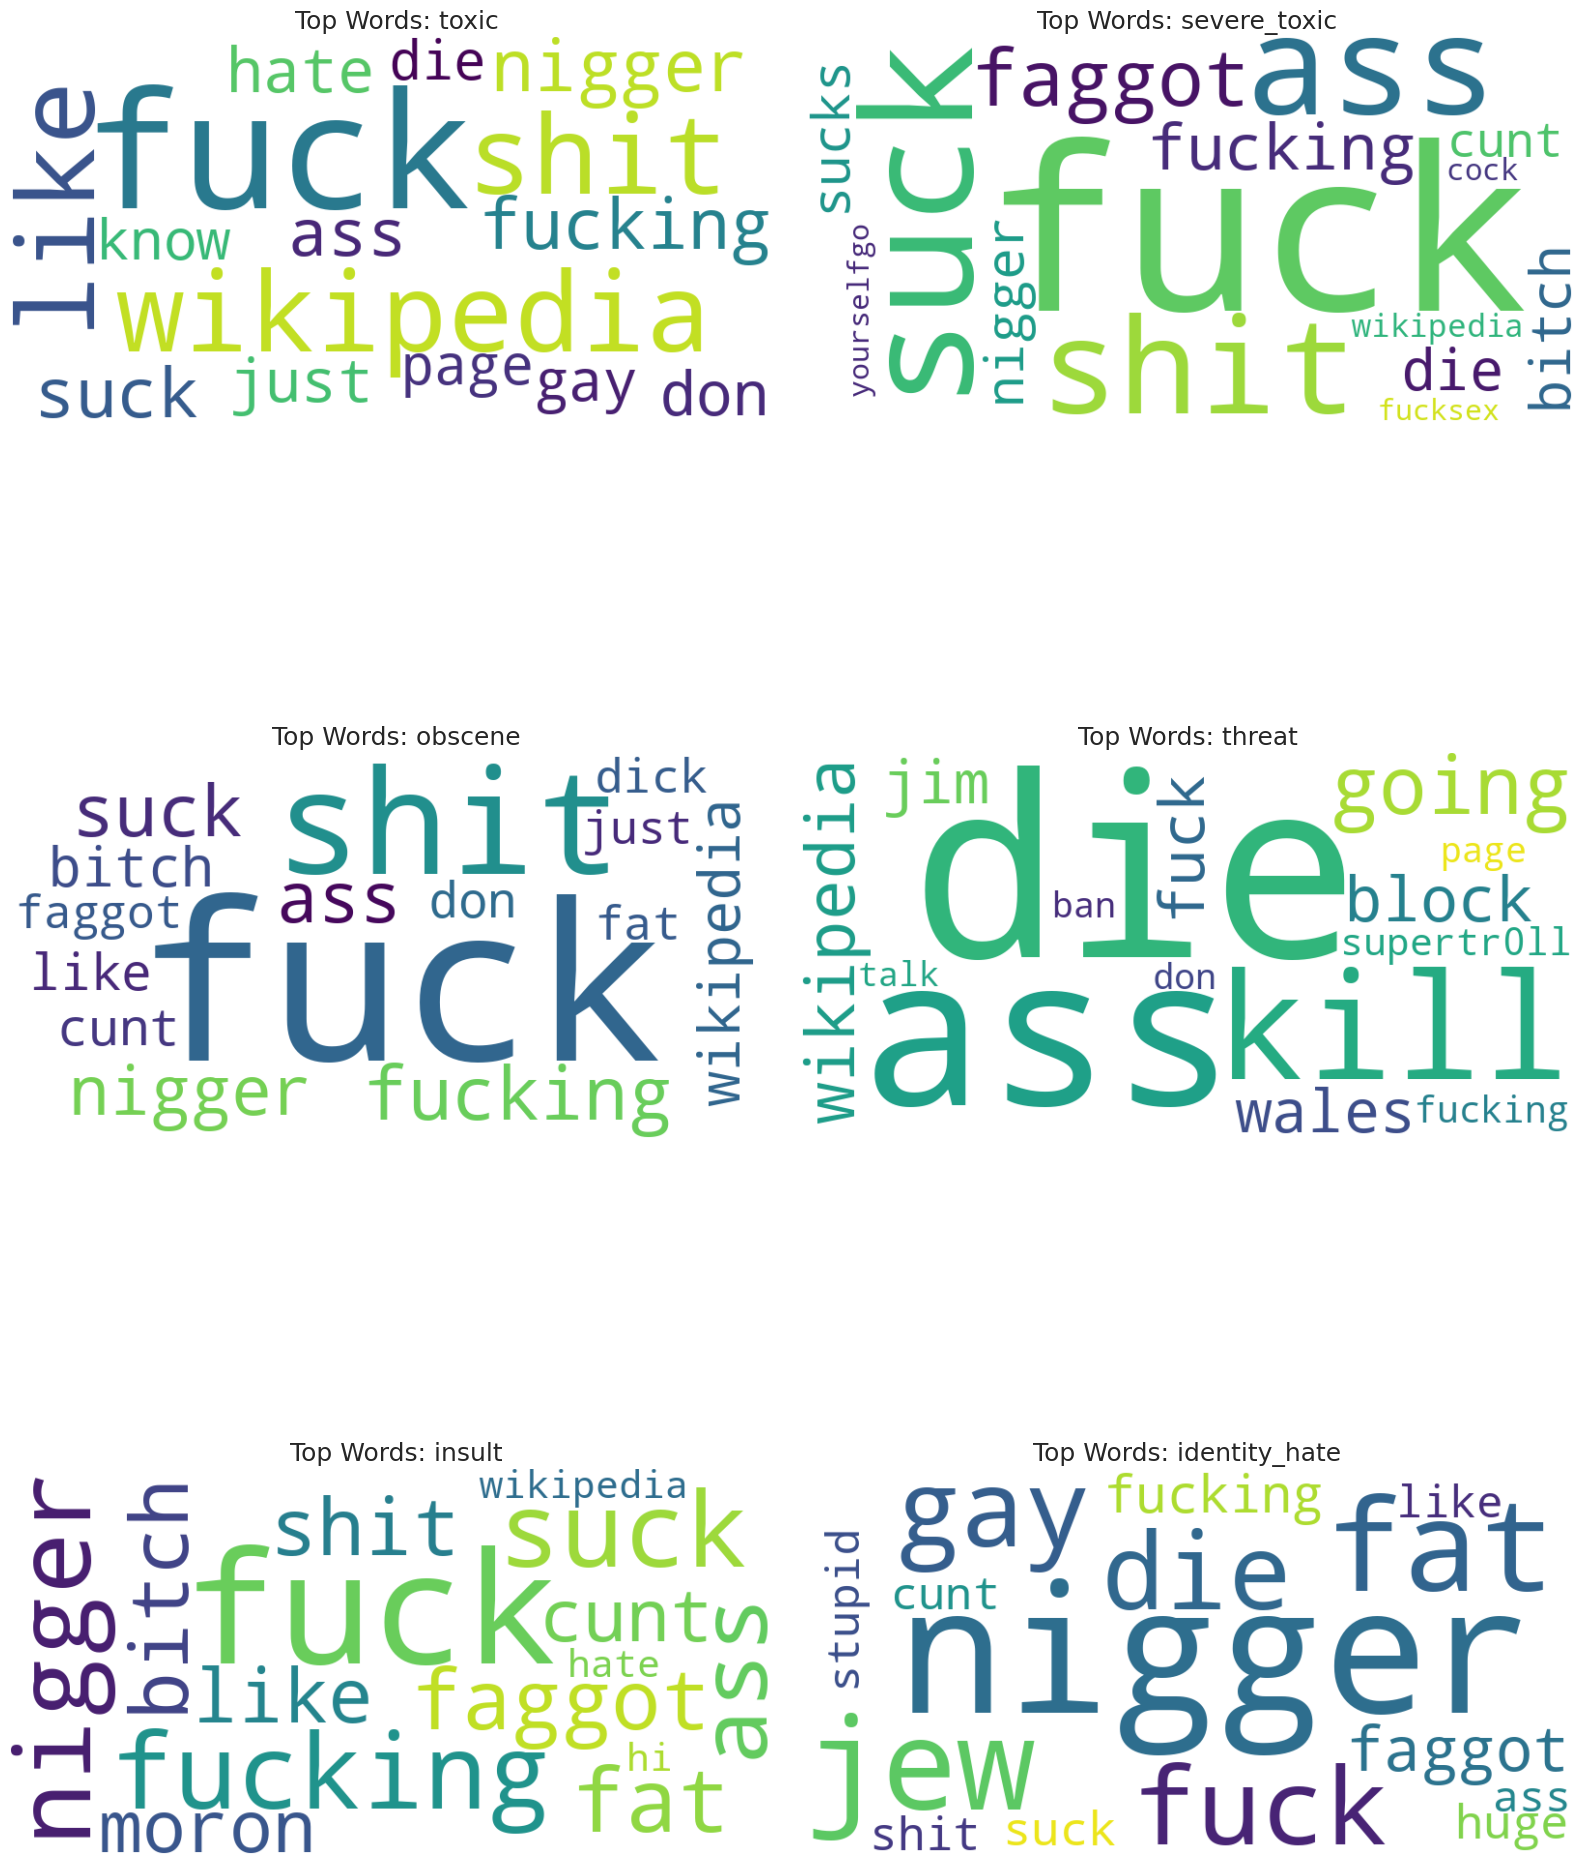

In [17]:
import math
n_labels = len(label_cols)
rows = math.ceil(n_labels / 2)
cols = 2
fig, axes = plt.subplots(rows, cols, figsize=(16, 8*rows))
axes = axes.flatten()

for ax, label in zip(axes, label_cols):
    uni_df = label_summary[label][0].head(50)
    freqs = dict(zip(uni_df["word"], uni_df["count"]))
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(freqs)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Top Words: {label}", fontsize=18)

for i in range(len(label_cols), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Extreme Examples

In [18]:
train_data["toxicity_sum"] = train_data[label_cols].sum(axis=1)

short_toxic = (
    train_data[train_data["toxic"] == 1]
    .sort_values("word_len", ascending=True)
    [["word_len", "comment_text"] + label_cols]
    .head(10))

long_toxic = (
    train_data[train_data["toxic"] == 1]
    .sort_values("word_len", ascending=False)
    [["word_len", "comment_text"] + label_cols]
    .head(10))

display(short_toxic)
display(long_toxic)

most_multi_label = (
    train_data[train_data["toxicity_sum"] >= 3]
    .sort_values("toxicity_sum", ascending=False)
    [["toxicity_sum", "comment_text"] + label_cols]
    .head(20))
display(most_multi_label)

,word_len,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
121074,2,you suck,1,0,1,0,1,0
156926,2,YOU SUCK!!!!!!!!!!!!!!!!!!!!,1,0,1,0,1,0
59615,2,Fuck you!216.102.76.214,1,0,1,0,1,0
134289,2,YOU\n\n CUNT,1,0,1,0,1,0
20953,2,O\n DIEEEEEEEEEEEEEEEEEEEEE,1,0,0,0,0,0
113646,2,HA GAAAAAAAAAYYYYY,1,0,0,0,0,1
158631,2,Screw you.149.254.186.158,1,0,0,0,0,0
111531,2,Stupid Liberals!!!!!!!!!!!!!!!!!!!!!!!!,1,0,0,0,1,0
88025,2,Nerd\n\nNeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeerd,1,0,0,0,1,0
16120,2,u suckkkkkkkkkkkkkkk,1,0,1,0,1,0


,word_len,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
140904,1411,I AM AN LOSER ==== I AM AN LOSER == == I AM AN...,1,0,0,0,0,0
4712,1403,do go fuck off bastard\nDo Yyou Have a life?\n...,1,1,1,1,1,0
81295,1354,Take that! \n\nIN THE ASS IN THE ASS IN THE AS...,1,1,1,0,0,0
35817,1344,What is rong with you u pervert i ahte u just ...,1,0,1,0,1,0
27148,1250,DAMN YOU U CUNT DAMN YOU U CUNT DAMN YOU U CUN...,1,1,1,0,1,0
136531,1250,SUCK MY COCK D SUCK MY COCK D SUCK MY COCK D S...,1,1,1,0,1,0
76598,1250,DIE FAG DIE FAG DIE FAG DIE FAG DIE FAG DIE FA...,1,0,0,0,0,0
32143,1250,PIG PIG PIG PIG PIG PIG PIG PIG PIG PIG PIG PI...,1,0,0,0,0,0
153353,1247,FAT JEW FAT JEW FAT JEW FAT JEW FAT JEW FAT JE...,1,0,0,0,1,1
32400,1238,THAT WAS REALLY MILLESECONDS WASNT IT BITCH \n...,1,0,1,0,1,1


,toxicity_sum,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
65075,6,FAGGOTS! YO FUCKER IT WAS FUCKING HAYES YOU F...,1,1,1,1,1,1
123794,6,She is a Motherfucker \n\nI will block you Mot...,1,1,1,1,1,1
157428,6,Ok.... \n\nBitch i swear to God i will fuckin ...,1,1,1,1,1,1
13964,6,I am going to murder ZimZalaBim ST47 for being...,1,1,1,1,1,1
1017,6,WOULDN'T BE THE FIRST TIME BITCH. FUCK YOU I'L...,1,1,1,1,1,1
151131,6,"LGBT \n\nyou little fuck , are you a fag , tha...",1,1,1,1,1,1
22158,6,FUCK YOU!!!!!!!!!!!! YOU FUCKING NIGGER BAG OF...,1,1,1,1,1,1
106617,6,", I hope your retarded kids get anal raped and...",1,1,1,1,1,1
118928,6,You god damn son of a bitch you fucking blocke...,1,1,1,1,1,1
99819,6,Glenn Beck is a faggot. He likes dick in his a...,1,1,1,1,1,1


## Preprocessing

In [19]:
RE_MULTI_SPACE = re.compile(r"\s+")
RE_REPEAT_CHAR = re.compile(r"(.)\1{2,}")
RE_CENSORED_F = re.compile(r"f[\W_]*\*+[\W_]*k", re.IGNORECASE)
RE_HTML_TAGS = re.compile(r"<.*?>")

def normalize_whitespace(text: str) -> str:
    text = RE_MULTI_SPACE.sub(" ", text)
    return text.strip()

def normalize_repeated_chars(text: str) -> str:
    return RE_REPEAT_CHAR.sub(r"\1\1", text)

def normalize_censored_profanity(text: str) -> str:
    text = re.sub(r"f[\W_]*\*+[\W_]*\*+[\W_]*\*+[\W_]*k", "fuck", text, flags=re.IGNORECASE)
    text = re.sub(r"f[\W_]*\*+[\W_]*k", "fuck", text, flags=re.IGNORECASE)
    return text

def strip_html(text: str) -> str:
    return RE_HTML_TAGS.sub(" ", text)

def basic_clean(text: str) -> str:
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = strip_html(text)
    text = normalize_censored_profanity(text)
    text = normalize_repeated_chars(text)
    text = normalize_whitespace(text)
    return text

train_data["text_raw"] = train_data["comment_text"].astype(str)
train_data["text_clean_tfidf"] = train_data["text_raw"].apply(basic_clean)
train_data["any_toxic"] = (train_data[label_cols].sum(axis=1) > 0).astype(int)

def light_clean(text: str) -> str:
    if not isinstance(text, str):
        text = str(text)
    text = normalize_whitespace(text)
    return text

train_data["text_for_bert"] = train_data["text_raw"].apply(light_clean)

train_df, val_df = train_test_split(
    train_data,
    test_size=0.2,
    random_state=42,
    stratify=train_data["any_toxic"])

print(train_df.shape, val_df.shape)

(127656, 22) (31915, 22)


## TF-IDF Vectorization

In [20]:
tfidf = TfidfVectorizer(
    min_df=5,
    max_df=0.9,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words="english")

X_train = tfidf.fit_transform(train_df["text_clean_tfidf"])
X_val = tfidf.transform(val_df["text_clean_tfidf"])

y_train = train_df[label_cols].values
y_val = val_df[label_cols].values

print(X_train.shape, X_val.shape)

(127656, 106143) (31915, 106143)


## Baseline Models

In [21]:
logreg = OneVsRestClassifier(
    LogisticRegression(max_iter=2000, C=2.0, class_weight='balanced')
)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict_proba(X_val)
auc_scores_logreg = {label: roc_auc_score(y_val[:, i], logreg_pred[:, i]) for i, label in enumerate(label_cols)}
print("LogReg Mean ROC-AUC:", sum(auc_scores_logreg.values()) / len(label_cols))

svm = OneVsRestClassifier(LinearSVC(C=1.0, class_weight='balanced'))
svm.fit(X_train, y_train)
svm_dec = svm.decision_function(X_val)
auc_scores_svm = {label: roc_auc_score(y_val[:, i], svm_dec[:, i]) for i, label in enumerate(label_cols)}
print("SVM Mean ROC-AUC:", sum(auc_scores_svm.values()) / len(label_cols))

selector = SelectKBest(chi2, k=5000)
X_train_rf = selector.fit_transform(X_train, y_train)
X_val_rf = selector.transform(X_val)
rf = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, n_jobs=-1))
rf.fit(X_train_rf, y_train)
rf_pred = rf.predict_proba(X_val_rf)
auc_scores_rf = {label: roc_auc_score(y_val[:, i], rf_pred[:, i]) for i, label in enumerate(label_cols)}
print("RF Mean ROC-AUC:", sum(auc_scores_rf.values()) / len(label_cols))

baseline_results = pd.DataFrame({
    "LogReg": auc_scores_logreg,
    "LinearSVM": auc_scores_svm,
    "RandomForest": auc_scores_rf
})
baseline_results.loc["mean"] = baseline_results.mean()
display(baseline_results)

LogReg Mean ROC-AUC: 0.9777415892847156


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


SVM Mean ROC-AUC: 0.9668421239626204
RF Mean ROC-AUC: 0.9441243188771749


,LogReg,LinearSVM,RandomForest
toxic,0.972013,0.965272,0.950535
severe_toxic,0.980805,0.961307,0.957485
obscene,0.986242,0.980009,0.980933
threat,0.978170,0.967604,0.889362
insult,0.978868,0.969786,0.966706
identity_hate,0.970351,0.957075,0.919726
mean,0.977742,0.966842,0.944124


## CNN Model Setup & Training

In [22]:
MAX_WORDS = 50000
MAX_LEN = 150

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<UNK>")
tokenizer.fit_on_texts(train_df["text_for_bert"])
X_train_seq = tokenizer.texts_to_sequences(train_df["text_for_bert"])
X_val_seq = tokenizer.texts_to_sequences(val_df["text_for_bert"])
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN)
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN)

cnn_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_WORDS, output_dim=128),
    Conv1D(filters=128, kernel_size=5, activation="relu"),
    GlobalMaxPool1D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(6, activation="sigmoid")
])

cnn_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["AUC"])

history_cnn = cnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    batch_size=128,
    epochs=3
)

cnn_pred = cnn_model.predict(X_val_pad)
auc_scores_cnn = {label: roc_auc_score(y_val[:, i], cnn_pred[:, i]) for i, label in enumerate(label_cols)}
print("CNN Mean ROC-AUC:", np.mean(list(auc_scores_cnn.values())))
display(auc_scores_cnn)

2025-12-12 05:19:20.107072: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/3
998/998 ━━━━━━━━━━━━━━━━━━━━ 147s 145ms/step - AUC: 0.8751 - loss: 0.1198 - val_AUC: 0.9803 - val_loss: 0.0494
Epoch 2/3
998/998 ━━━━━━━━━━━━━━━━━━━━ 203s 146ms/step - AUC: 0.9867 - loss: 0.0432 - val_AUC: 0.9821 - val_loss: 0.0479
Epoch 3/3
998/998 ━━━━━━━━━━━━━━━━━━━━ 144s 144ms/step - AUC: 0.9927 - loss: 0.0341 - val_AUC: 0.9702 - val_loss: 0.0514
998/998 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step
CNN Mean ROC-AUC: 0.9780418490365851


{'toxic': 0.9704459570318403,
 'severe_toxic': 0.9861001654384118,
 'obscene': 0.988700029669562,
 'threat': 0.9739312766310912,
 'insult': 0.9827037701552825,
 'identity_hate': 0.9663698952933222}

## CNN Grid Search Results

In [23]:
param_data = [
    (128, 3, 0.3, 0.001, 0.9766183),
    (128, 3, 0.3, 0.0005, 0.9736294),
    (128, 3, 0.5, 0.001, 0.9732230),
    (128, 3, 0.5, 0.0005, 0.9724355),
    (128, 5, 0.3, 0.001, 0.9752305),
    (128, 5, 0.3, 0.0005, 0.9745228),
    (128, 5, 0.5, 0.001, 0.9750614),
    (128, 5, 0.5, 0.0005, 0.9748846),
    (256, 3, 0.3, 0.001, 0.9760320),
    (256, 3, 0.3, 0.0005, 0.9749550),
    (256, 3, 0.5, 0.001, 0.9754367),
    (256, 3, 0.5, 0.0005, 0.9738582),
    (256, 5, 0.3, 0.001, 0.9792438),
    (256, 5, 0.3, 0.0005, 0.9749289),
    (256, 5, 0.5, 0.001, 0.9755924),
    (256, 5, 0.5, 0.0005, 0.9757528),
]
param_df = pd.DataFrame(param_data, columns=["filters", "kernel_size", "dropout", "lr", "auc"])
display(param_df)

,filters,kernel_size,dropout,lr,auc
0,128,3,0.3,0.0010,0.976618
1,128,3,0.3,0.0005,0.973629
2,128,3,0.5,0.0010,0.973223
3,128,3,0.5,0.0005,0.972436
4,128,5,0.3,0.0010,0.975231
5,128,5,0.3,0.0005,0.974523
6,128,5,0.5,0.0010,0.975061
7,128,5,0.5,0.0005,0.974885
8,256,3,0.3,0.0010,0.976032
9,256,3,0.3,0.0005,0.974955


## Best CNN Model & Checkpointing

In [24]:
cnn_best = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_WORDS, output_dim=128),
    Conv1D(filters=256, kernel_size=5, activation="relu"),
    GlobalMaxPool1D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(6, activation="sigmoid")
])

cnn_best.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["AUC"]
)

checkpoint_path = "cnn_best_epoch.keras"
callbacks = [
    ModelCheckpoint(checkpoint_path, monitor="val_AUC", mode="max", save_best_only=True),
    EarlyStopping(monitor="val_AUC", mode="max", patience=2, restore_best_weights=True)
]

history = cnn_best.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,        
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

cnn_best = load_model("cnn_best_epoch.keras")
pred = cnn_best.predict(X_val_pad)
cnn_auc = {label: roc_auc_score(y_val[:, i], pred[:, i]) for i, label in enumerate(label_cols)}
cnn_auc["mean"] = np.mean(list(cnn_auc.values()))
display(cnn_auc)

Epoch 1/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 257s 256ms/step - AUC: 0.8838 - loss: 0.1150 - val_AUC: 0.9807 - val_loss: 0.0491
Epoch 2/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 263s 263ms/step - AUC: 0.9863 - loss: 0.0436 - val_AUC: 0.9784 - val_loss: 0.0488
Epoch 3/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 257s 257ms/step - AUC: 0.9929 - loss: 0.0338 - val_AUC: 0.9663 - val_loss: 0.0538
998/998 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step


{'toxic': 0.9740092036645169,
 'severe_toxic': 0.9865718464275156,
 'obscene': 0.9890868696058348,
 'threat': 0.9590451260492883,
 'insult': 0.9829703746982281,
 'identity_hate': 0.9560637616930262,
 'mean': 0.9746245303564017}

## Cross-Validation Stability

Running 5-Fold Cross-Validation...
Fold 1 AUC: 0.9783
Fold 2 AUC: 0.9792
Fold 3 AUC: 0.9806
Fold 4 AUC: 0.9796
Fold 5 AUC: 0.9800


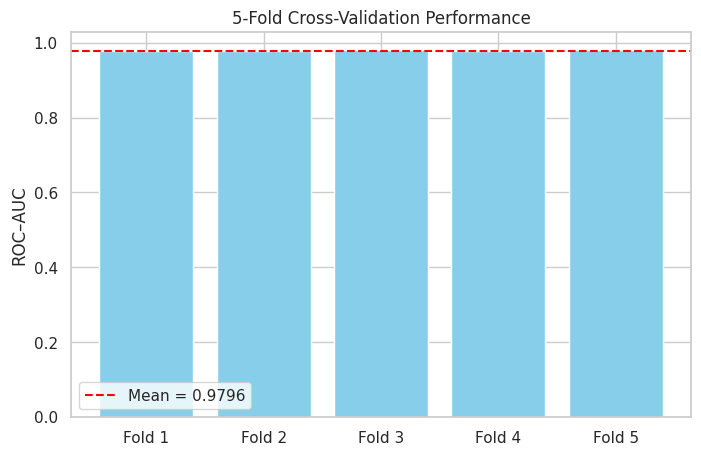

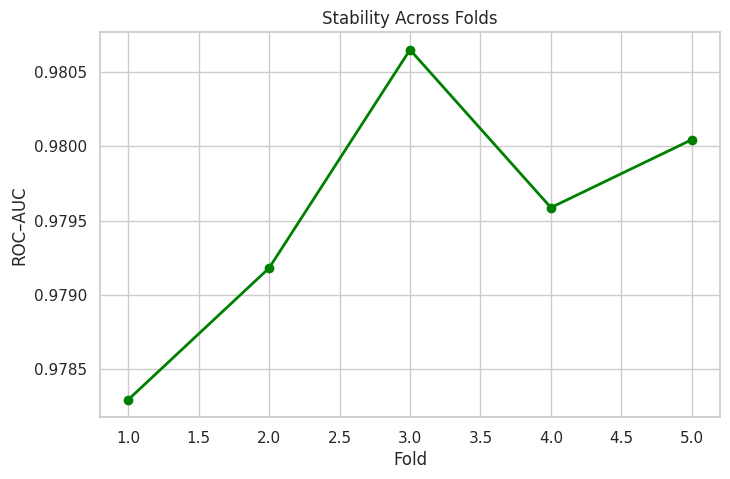

In [25]:
from scipy.sparse import vstack

X_full_tfidf = vstack([X_train, X_val])
y_full = np.vstack([y_train, y_val])

y_split_ref = y_full[:, 0]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
model_cv = OneVsRestClassifier(LogisticRegression(max_iter=200, n_jobs=-1))

print("Running 5-Fold Cross-Validation...")

for fold, (idx_tr, idx_val) in enumerate(skf.split(X_full_tfidf, y_split_ref)):
    model_cv.fit(X_full_tfidf[idx_tr], y_full[idx_tr])
    preds = model_cv.predict_proba(X_full_tfidf[idx_val])
    score = roc_auc_score(y_full[idx_val], preds, average='macro')
    cv_scores.append(score)
    print(f"Fold {fold+1} AUC: {score:.4f}")

plt.figure(figsize=(8,5))
plt.bar([f"Fold {i+1}" for i in range(5)], cv_scores, color="skyblue")
plt.axhline(np.mean(cv_scores), color='red', linestyle='--', label=f"Mean = {np.mean(cv_scores):.4f}")
plt.ylabel("ROC–AUC")
plt.title("5-Fold Cross-Validation Performance")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(range(1,6), cv_scores, marker='o', linewidth=2, color="green")
plt.xlabel("Fold")
plt.ylabel("ROC–AUC")
plt.title("Stability Across Folds")
plt.grid(True)
plt.show()

## Model Selection Comparison

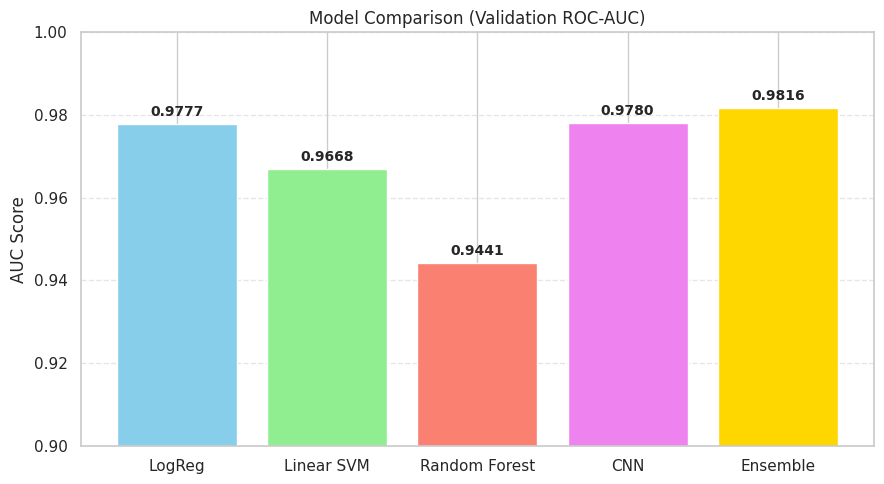

In [30]:
ensemble_pred = (logreg_pred + cnn_pred) / 2
ensemble_auc = roc_auc_score(y_val, ensemble_pred, average='macro')

models = ["LogReg", "Linear SVM", "Random Forest", "CNN", "Ensemble"]

scores = [
    sum(auc_scores_logreg.values()) / len(label_cols),
    sum(auc_scores_svm.values()) / len(label_cols),
    sum(auc_scores_rf.values()) / len(label_cols),
    np.mean(list(auc_scores_cnn.values())),
    ensemble_auc
]

plt.figure(figsize=(9, 5))
bars = plt.bar(models, scores, color=["skyblue", "lightgreen", "salmon", "violet", "gold"])
plt.title("Model Comparison (Validation ROC-AUC)")
plt.ylabel("AUC Score")
plt.ylim(0.90, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
             f"{score:.4f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Learning Curve Analysis

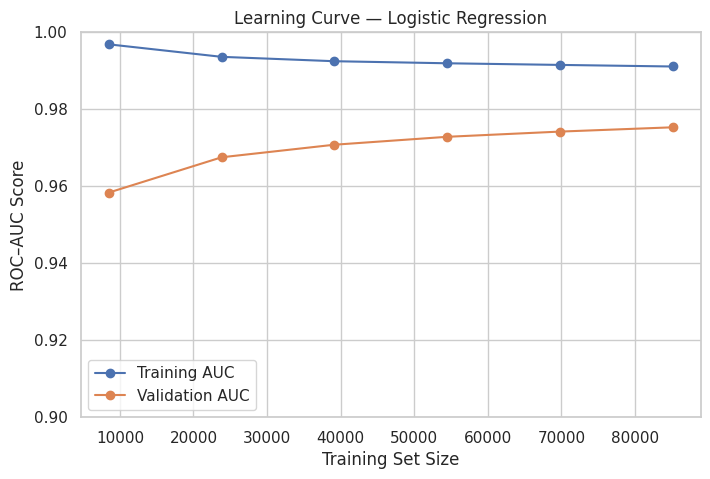

In [27]:
model_lc = OneVsRestClassifier(LogisticRegression(max_iter=300))

train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_lc,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=3,
    scoring="roc_auc_ovr_weighted",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, "o-", label="Training AUC")
plt.plot(train_sizes, val_mean, "o-", label="Validation AUC")
plt.title("Learning Curve — Logistic Regression")
plt.xlabel("Training Set Size")
plt.ylabel("ROC–AUC Score")
plt.grid(True)
plt.legend()
plt.ylim(0.90, 1.00)
plt.show()

## Error Analysis

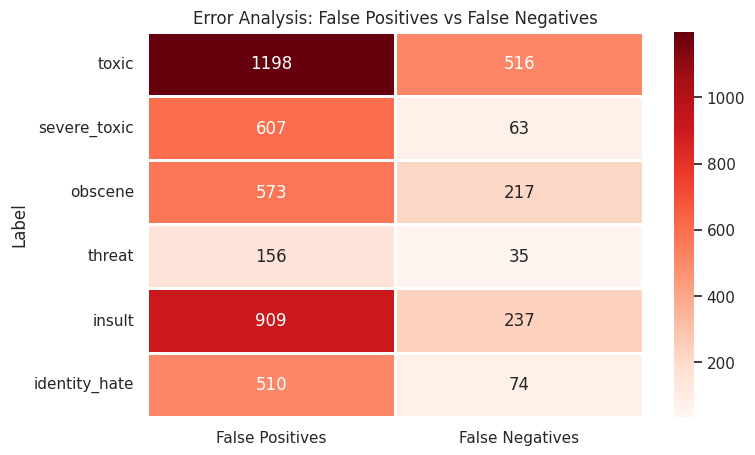

,False Positives,False Negatives
Label,,
toxic,1198,516
severe_toxic,607,63
obscene,573,217
threat,156,35
insult,909,237
identity_hate,510,74


In [29]:
pred_binary = (logreg_pred >= 0.5).astype(int)

fp_counts = []
fn_counts = []

for i, label in enumerate(label_cols):
    fp = np.sum((y_val[:, i] == 0) & (pred_binary[:, i] == 1))
    fn = np.sum((y_val[:, i] == 1) & (pred_binary[:, i] == 0))
    
    fp_counts.append(fp)
    fn_counts.append(fn)

error_df = pd.DataFrame({
    'Label': label_cols, 
    'False Positives': fp_counts, 
    'False Negatives': fn_counts
}).set_index('Label')

plt.figure(figsize=(8, 5))
sns.heatmap(error_df, annot=True, fmt="d", cmap="Reds", linewidths=1)
plt.title("Error Analysis: False Positives vs False Negatives")
plt.show()

display(error_df)

## Threshold Optimization

Finding optimal thresholds per label...
toxic: Best Threshold=0.70 (F1=0.7744)
severe_toxic: Best Threshold=0.90 (F1=0.4822)
obscene: Best Threshold=0.80 (F1=0.8059)
threat: Best Threshold=0.85 (F1=0.4689)
insult: Best Threshold=0.75 (F1=0.7278)
identity_hate: Best Threshold=0.80 (F1=0.4577)


,Optimal Threshold,False Positives,False Negatives
Label,,,
toxic,0.70,553,772
severe_toxic,0.90,249,129
obscene,0.80,248,373
threat,0.85,62,49
insult,0.75,499,389
identity_hate,0.80,233,113


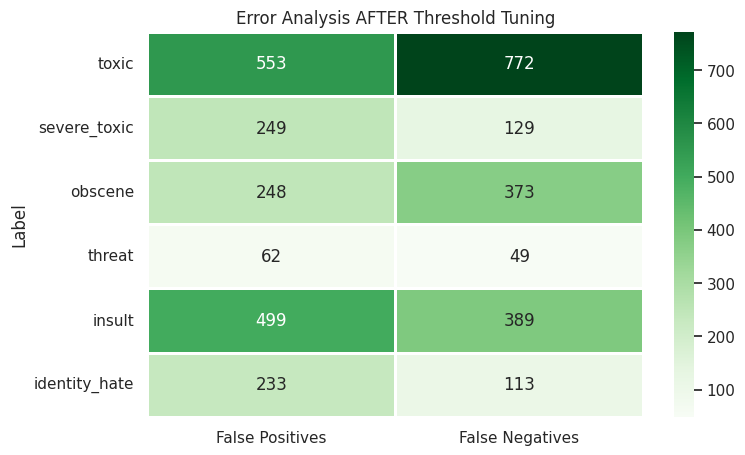

In [31]:
from sklearn.metrics import f1_score

best_thresholds = {}
val_probs = logreg.predict_proba(X_val)

print("Finding optimal thresholds per label...")
for i, label in enumerate(label_cols):
    y_true = y_val[:, i]
    preds = val_probs[:, i]
    
    best_score = 0
    best_thresh = 0.5
    
    for thresh in np.arange(0.1, 0.95, 0.05):
        score = f1_score(y_true, (preds >= thresh).astype(int))
        if score > best_score:
            best_score = score
            best_thresh = thresh
            
    best_thresholds[label] = best_thresh
    print(f"{label}: Best Threshold={best_thresh:.2f} (F1={best_score:.4f})")

fp_counts_opt = []
fn_counts_opt = []

for i, label in enumerate(label_cols):
    thresh = best_thresholds[label]
    pred_binary_opt = (val_probs[:, i] >= thresh).astype(int)
    
    fp = np.sum((y_val[:, i] == 0) & (pred_binary_opt == 1))
    fn = np.sum((y_val[:, i] == 1) & (pred_binary_opt == 0))
    
    fp_counts_opt.append(fp)
    fn_counts_opt.append(fn)

error_df_opt = pd.DataFrame({
    'Label': label_cols, 
    'Optimal Threshold': [best_thresholds[l] for l in label_cols],
    'False Positives': fp_counts_opt, 
    'False Negatives': fn_counts_opt
}).set_index('Label')

display(error_df_opt)

plt.figure(figsize=(8, 5))
sns.heatmap(error_df_opt[['False Positives', 'False Negatives']], annot=True, fmt="d", cmap="Greens", linewidths=1)
plt.title("Error Analysis AFTER Threshold Tuning")
plt.show()

## LightGBM

In [32]:
from lightgbm import LGBMClassifier

print("Training LightGBM (Gradient Boosting)...")

X_train_rf = selector.transform(X_train)
X_val_rf = selector.transform(X_val)

lgbm = OneVsRestClassifier(LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1))
lgbm.fit(X_train_rf, y_train)

lgbm_pred = lgbm.predict_proba(X_val_rf)

auc_scores_lgbm = {label: roc_auc_score(y_val[:, i], lgbm_pred[:, i]) for i, label in enumerate(label_cols)}
print("LightGBM Mean ROC-AUC:", sum(auc_scores_lgbm.values()) / len(label_cols))
display(auc_scores_lgbm)

Training LightGBM (Gradient Boosting)...
[LightGBM] [Info] Number of positive: 12248, number of negative: 115408
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.102120 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 236546
[LightGBM] [Info] Number of data points in the train set: 127656, number of used features: 1958
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.095945 -> initscore=-2.243111
[LightGBM] [Info] Start training from score -2.243111
[LightGBM] [Info] Number of positive: 1290, number of negative: 126366
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.047401 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 236546
[LightGBM] [Info] Number of data points in the train set: 127656, number of used features: 1958
[LightGBM] [Info] [binary:Boos

{'toxic': 0.9577448558749787,
 'severe_toxic': 0.9752675797760618,
 'obscene': 0.9833035225634057,
 'threat': 0.9230547076296653,
 'insult': 0.9719981886576776,
 'identity_hate': 0.9508823984278874}

## LightGBM Visualizations & Final Comparison

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


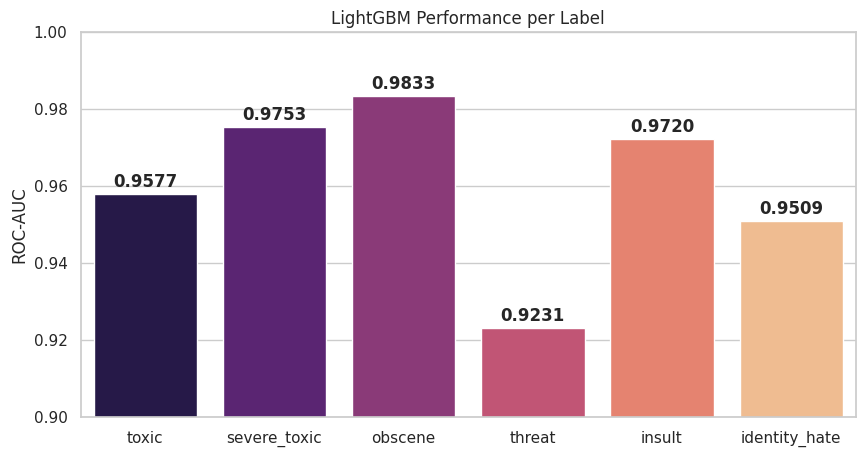

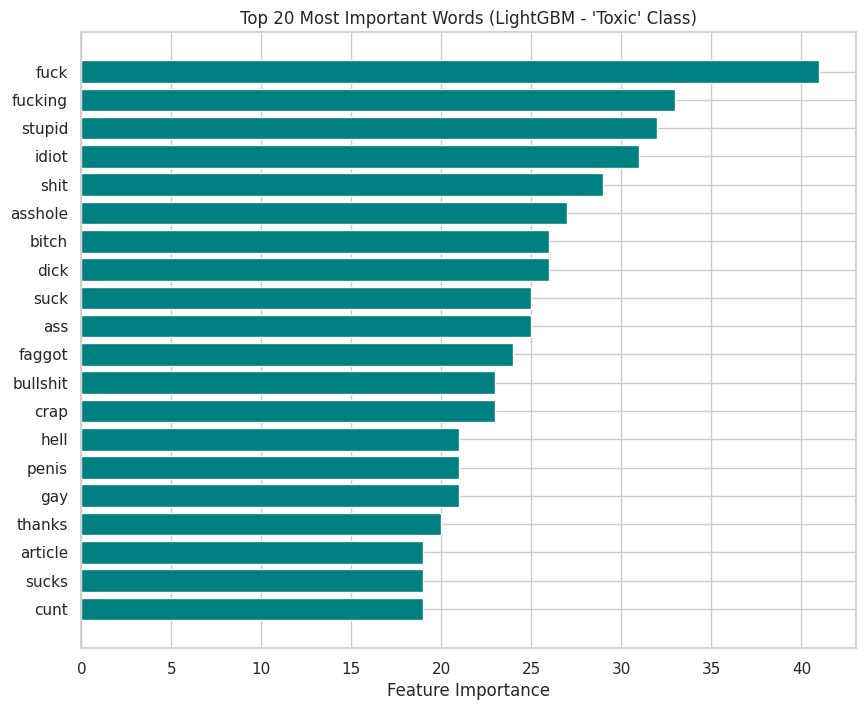

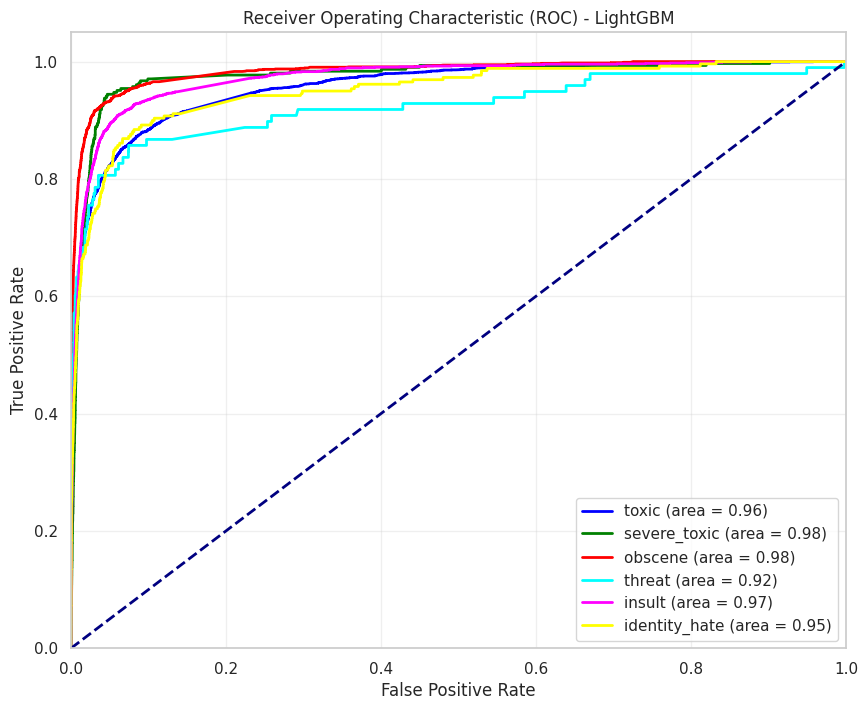

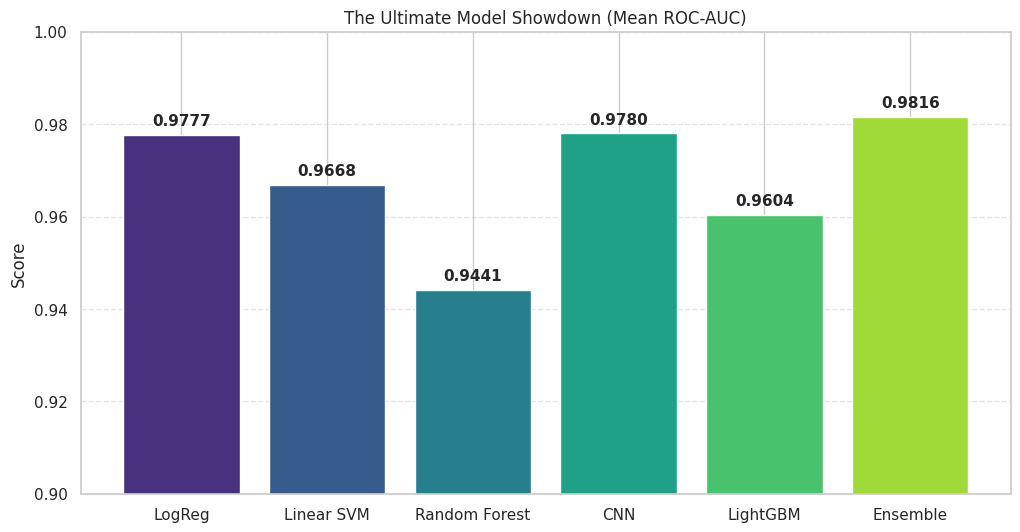

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

lgbm_scores = list(auc_scores_lgbm.values())
labels = list(auc_scores_lgbm.keys())

plt.figure(figsize=(10, 5))
sns.barplot(x=labels, y=lgbm_scores, palette="magma")
plt.ylim(0.90, 1.0)
plt.title("LightGBM Performance per Label")
plt.ylabel("ROC-AUC")
for i, v in enumerate(lgbm_scores):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

feature_names = np.array(tfidf.get_feature_names_out())
selected_mask = selector.get_support()
selected_features = feature_names[selected_mask]

importance = lgbm.estimators_[0].feature_importances_
sorted_idx = np.argsort(importance)[-20:]

plt.figure(figsize=(10, 8))
plt.barh(selected_features[sorted_idx], importance[sorted_idx], color='teal')
plt.title("Top 20 Most Important Words (LightGBM - 'Toxic' Class)")
plt.xlabel("Feature Importance")
plt.show()

plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow']

for i, label in enumerate(label_cols):
    fpr, tpr, _ = roc_curve(y_val[:, i], lgbm_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{label} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - LightGBM')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

all_models = ["LogReg", "Linear SVM", "Random Forest", "CNN", "LightGBM", "Ensemble"]
all_scores = [
    sum(auc_scores_logreg.values()) / len(label_cols),
    sum(auc_scores_svm.values()) / len(label_cols),
    sum(auc_scores_rf.values()) / len(label_cols),
    np.mean(list(auc_scores_cnn.values())),
    sum(auc_scores_lgbm.values()) / len(label_cols),
    ensemble_auc
]

plt.figure(figsize=(12, 6))
bars = plt.bar(all_models, all_scores, color=sns.color_palette("viridis", len(all_models)))
plt.ylim(0.90, 1.0)
plt.title("The Ultimate Model Showdown (Mean ROC-AUC)")
plt.ylabel("Score")

for bar, score in zip(bars, all_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
             f"{score:.4f}", ha='center', fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()